# IN403 – Unit 4 Lab: Computer Vision in Practice (PyTorch)

**Theme:** From *classification* to *detection* — and how to deploy vision systems responsibly.

## What you will build
1) A **vision classifier** that predicts whether a patient/staff face image shows **mask_on** vs **mask_off** using **transfer learning**.
2) A quick **detection demo** showing the difference between *detecting* a face and *recognizing* identity.

## Files provided
- `IN403_Unit4_PPE_Image_Dataset.zip` (extract in Colab)

## What you submit
- Completed notebook (.ipynb)
- Model evaluation (accuracy + confusion matrix)
- A short deployment note: what risks exist and what guardrails you recommend


## 0) Setup


In [2]:
# Optional installs for Colab (uncomment if needed)
# !pip -q install torch torchvision scikit-learn matplotlib opencv-python

import os, zipfile
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1) Unzip dataset

**Student task:** Upload the zip to Colab, then run this cell.


In [3]:
zip_file = 'IN403_Unit4_PPE_Image_Dataset.zip'
data_root = 'ppe_data'

if not os.path.exists(data_root):
    os.makedirs(data_root, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(data_root)

train_path = os.path.join(data_root, 'train')
test_path  = os.path.join(data_root, 'test')
train_path, test_path


('ppe_data/train', 'ppe_data/test')

## 2) Load images with transforms

**Requirements:**
- Use data augmentation (random flip/rotation)
- Normalize with ImageNet stats for transfer learning


In [4]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

train_ds = datasets.ImageFolder(train_path, transform=train_tfms)
test_ds  = datasets.ImageFolder(test_path,  transform=test_tfms)

class_names = train_ds.classes
class_names


['mask_off', 'mask_on']

### Preview a few samples
Tip: the images are normalized; for display we unnormalize.


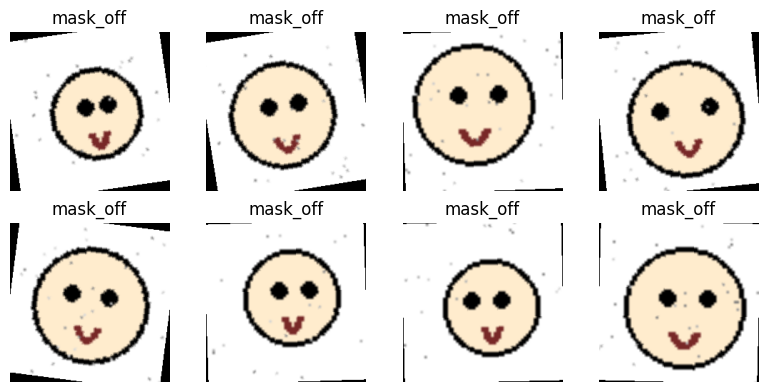

In [5]:
def unnormalize(img_t, mean=imagenet_mean, std=imagenet_std):
    img = img_t.clone()
    for c in range(3):
        img[c] = img[c]*std[c] + mean[c]
    return img.clamp(0,1)

plt.figure(figsize=(8,4))
for i in range(8):
    x, y = train_ds[i]
    plt.subplot(2,4,i+1)
    plt.imshow(unnormalize(x).permute(1,2,0))
    plt.title(class_names[y])
    plt.axis('off')
plt.tight_layout(); plt.show()


## 3) Build a transfer learning model

**Student task:**
- Load a pretrained `resnet18`
- Freeze the backbone
- Replace the final layer for 2 classes


In [7]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)


## 4) Train + evaluate

**Requirements:**
- Train for 5 epochs
- Plot training loss
- Compute test accuracy
- Display a confusion matrix


Epoch 1/5 | train_loss=0.3173
Epoch 2/5 | train_loss=0.0800
Epoch 3/5 | train_loss=0.0398
Epoch 4/5 | train_loss=0.0276
Epoch 5/5 | train_loss=0.0199


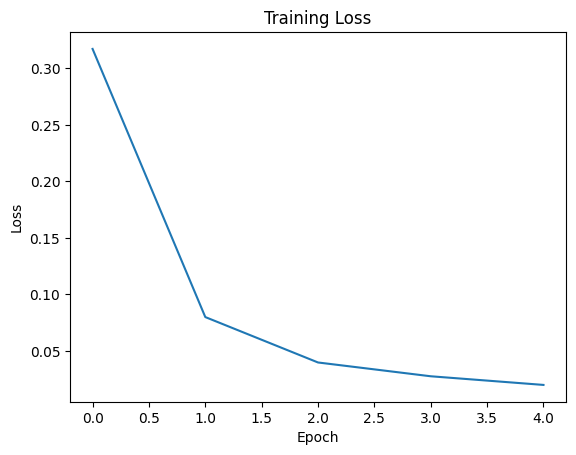

In [8]:
train_losses = []
epochs = 5

for e in range(epochs):
    model.train()
    running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_losses.append(running / len(train_dl.dataset))
    print(f"Epoch {e+1}/{epochs} | train_loss={train_losses[-1]:.4f}")

plt.figure(); plt.plot(train_losses); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()


Test accuracy: 1.0


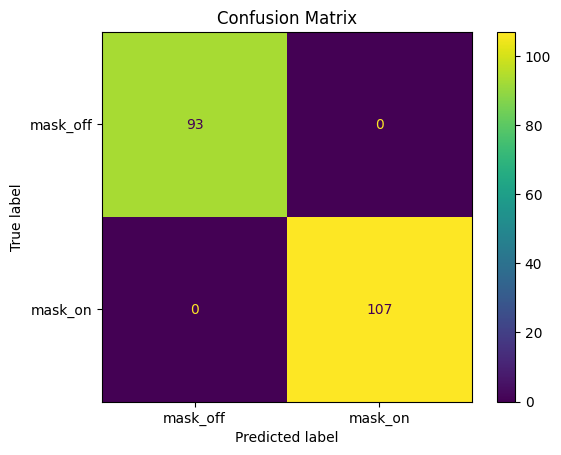

In [9]:
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(preds)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_pred)
y_true = np.concatenate(all_true)
acc = accuracy_score(y_true, y_pred)
print('Test accuracy:', acc)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot()
plt.title('Confusion Matrix'); plt.show()


## 5) Detection vs Recognition (concept demo)

A classifier predicts a label *given an image crop*. A detector finds *where* the object is in an image.

In healthcare, many use cases need **detection** (e.g., “is a mask present?”) rather than identity recognition.

**Student task:** Run this demo to detect a face in a sample image using OpenCV Haar cascades.
Then answer the reflection questions about why *detection* is often safer than *recognition*.


In [11]:
import cv2
from skimage import data

img = data.astronaut()  # sample image shipped with skimage
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

img2 = img.copy()
for (x,y,w,h) in faces:
    cv2.rectangle(img2, (x,y), (x+w, y+h), (255,0,0), 2)

plt.figure(figsize=(6,4))
plt.imshow(img2)
plt.title(f'Faces detected: {len(faces)}')
plt.axis('off')
plt.show()


AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

## 6) Reflection (answer in markdown)
1. What’s the difference between **classification** and **detection**?
2. Why might a hospital prefer *mask detection* over *identity recognition*?
3. What are 3 risks of deploying vision systems in public or clinical spaces?
4. What guardrails would you recommend (policy + technical)?

### Optional AI extension
- Fine-tune (unfreeze) the last ResNet block and see if accuracy improves.
